Размер обучающей выборки: 120
Размер тестовой выборки: 30
МЕТРИКИ КЛАССИФИКАЦИИ

✅ Accuracy (Точность): 0.9667 (96.67%)
   → Доля правильных предсказаний от всех предсказаний

🎯 Precision (Точность) по классам:
   setosa: 1.0000
   versicolor: 1.0000
   virginica: 0.9167
   → Доля правильных положительных предсказаний

📊 Recall (Полнота) по классам:
   setosa: 1.0000
   versicolor: 0.8889
   virginica: 1.0000
   → Доля правильно найденных объектов класса

⚖️ F1-Score по классам:
   setosa: 1.0000
   versicolor: 0.9412
   virginica: 0.9565
   → Среднее между Precision и Recall

📈 Усредненные метрики:
   Macro F1: 0.9659
   Micro F1: 0.9667
   Weighted F1: 0.9664

MATRIX ОШИБОК (Confusion Matrix)

Confusion Matrix (строки - true, столбцы - predicted):
[[10  0  0]
 [ 0  8  1]
 [ 0  0 11]]


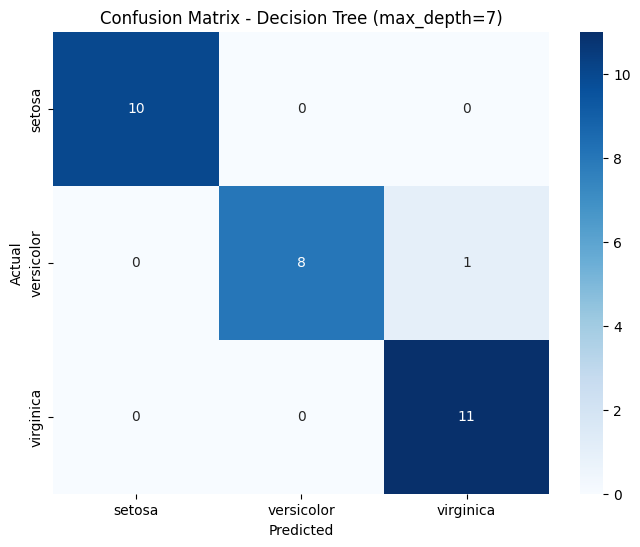


КЛАССИФИКАЦИОННЫЙ ОТЧЕТ
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.89      0.94         9
   virginica       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30


ROC-AUC МЕТРИКИ

🎯 ROC-AUC (One-vs-Rest): 0.9815
   → Чем выше, тем лучше (макс. 1.0)


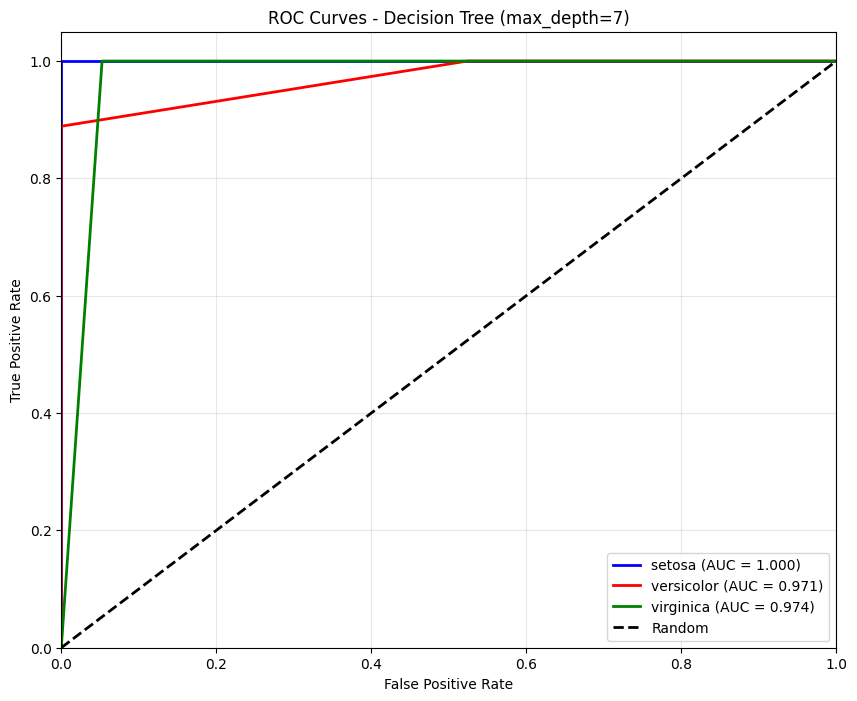


ДЕТАЛЬНЫЙ АНАЛИЗ ПО КЛАССАМ

🌺 setosa:
   TP (True Positives): 10
   FP (False Positives): 0
   FN (False Negatives): 0
   TN (True Negatives): 20
   Precision: 1.0000
   Recall (Sensitivity): 1.0000
   Specificity: 1.0000
   F1-Score: 1.0000

🌺 versicolor:
   TP (True Positives): 8
   FP (False Positives): 0
   FN (False Negatives): 1
   TN (True Negatives): 21
   Precision: 1.0000
   Recall (Sensitivity): 0.8889
   Specificity: 1.0000
   F1-Score: 0.9412

🌺 virginica:
   TP (True Positives): 11
   FP (False Positives): 1
   FN (False Negatives): 0
   TN (True Negatives): 18
   Precision: 0.9167
   Recall (Sensitivity): 1.0000
   Specificity: 0.9474
   F1-Score: 0.9565

СРАВНЕНИЕ ГЛУБИН ДЕРЕВА
 max_depth  accuracy  f1_macro  n_leaves
       1.0  0.633333  0.540230         2
       2.0  0.966667  0.965899         3
       3.0  1.000000  1.000000         5
       4.0  1.000000  1.000000         7
       5.0  1.000000  1.000000         8
       6.0  1.000000  1.000000         9
       7

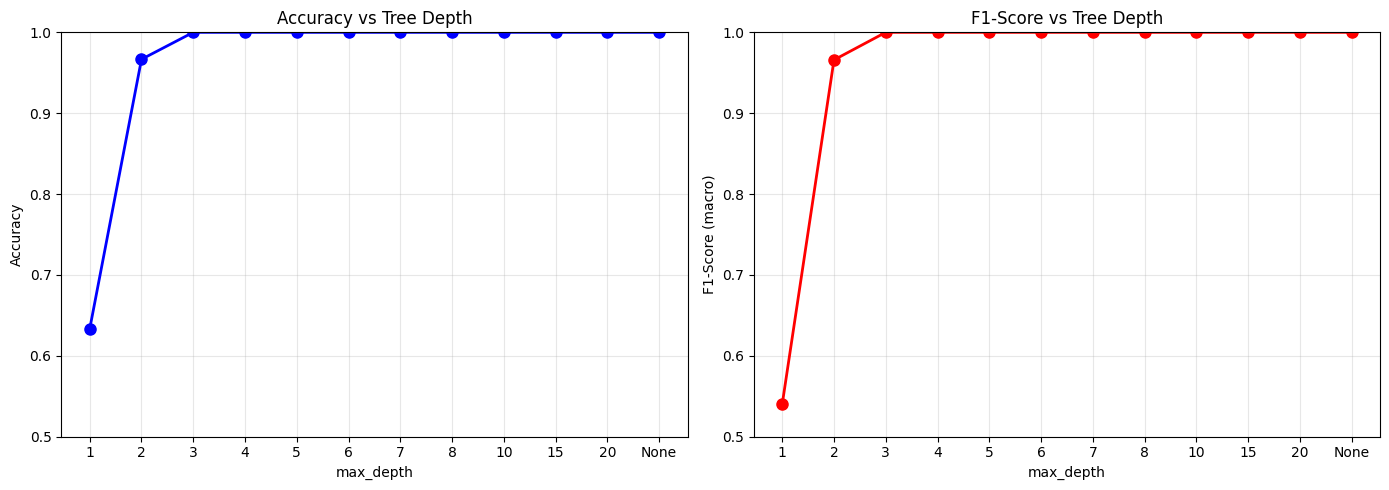

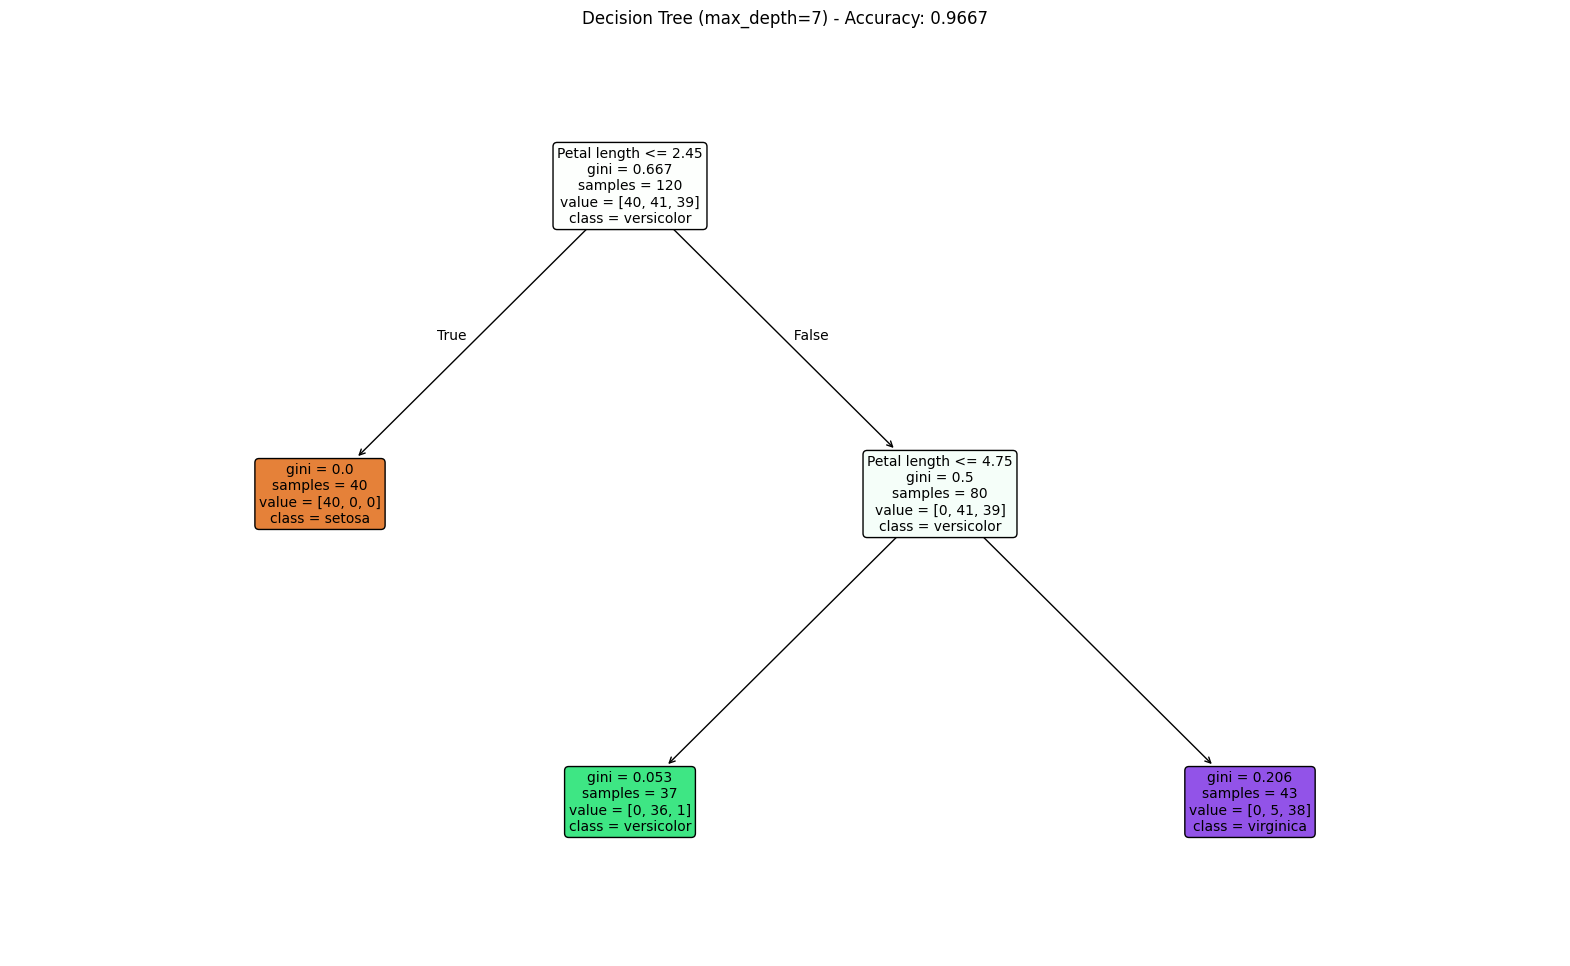


📊 ИТОГОВЫЙ ОТЧЕТ ПО МОДЕЛИ
      Метрика Значение
     Accuracy   0.9667
     Macro F1   0.9659
     Micro F1   0.9667
  Weighted F1   0.9664
ROC-AUC (OVR)   0.9815

🔍 АНАЛИЗ ОШИБОК

Количество ошибок: 1 из 30
Доля ошибок: 3.33%

Примеры ошибок (первые 5):
  Экземпляр 4:
    Признаки: [4.8 1.4]
    Истинный класс: versicolor
    Предсказанный: virginica
    Уверенность: 0.8837



In [4]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_auc_score, roc_curve)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных
iris = load_iris()
X = iris.data[:, 2:]  # petal length and width
y = iris.target

# 1. РАЗДЕЛЕНИЕ ДАННЫХ НА TRAIN/TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")

# 2. ОБУЧЕНИЕ
tree_clf = DecisionTreeClassifier(max_depth=2, random_state=42)
tree_clf.fit(X_train, y_train)

# 3. ПРЕДСКАЗАНИЯ
y_pred = tree_clf.predict(X_test)
y_pred_proba = tree_clf.predict_proba(X_test)  # Для ROC-AUC

# ============================================
# 4. МЕТРИКИ КЛАССИФИКАЦИИ
# ============================================

print("=" * 60)
print("МЕТРИКИ КЛАССИФИКАЦИИ")
print("=" * 60)

# 4.1 Accuracy (Точность)
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Accuracy (Точность): {accuracy:.4f} ({accuracy*100:.2f}%)")
print("   → Доля правильных предсказаний от всех предсказаний")

# 4.2 Precision (Точность для каждого класса)
precision = precision_score(y_test, y_pred, average=None)
print(f"\n🎯 Precision (Точность) по классам:")
for i, cls in enumerate(iris.target_names):
    print(f"   {cls}: {precision[i]:.4f}")
print("   → Доля правильных положительных предсказаний")

# 4.3 Recall (Полнота)
recall = recall_score(y_test, y_pred, average=None)
print(f"\n📊 Recall (Полнота) по классам:")
for i, cls in enumerate(iris.target_names):
    print(f"   {cls}: {recall[i]:.4f}")
print("   → Доля правильно найденных объектов класса")

# 4.4 F1-Score (Среднее гармоническое)
f1 = f1_score(y_test, y_pred, average=None)
print(f"\n⚖️ F1-Score по классам:")
for i, cls in enumerate(iris.target_names):
    print(f"   {cls}: {f1[i]:.4f}")
print("   → Среднее между Precision и Recall")

# 4.5 Macro/Micro/Weighted средние
print(f"\n📈 Усредненные метрики:")
print(f"   Macro F1: {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"   Micro F1: {f1_score(y_test, y_pred, average='micro'):.4f}")
print(f"   Weighted F1: {f1_score(y_test, y_pred, average='weighted'):.4f}")

# ============================================
# 5. CONFUSION MATRIX
# ============================================

print("\n" + "=" * 60)
print("MATRIX ОШИБОК (Confusion Matrix)")
print("=" * 60)

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix (строки - true, столбцы - predicted):")
print(cm)

# Визуализация
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix - Decision Tree (max_depth=7)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ============================================
# 6. CLASSIFICATION REPORT (Детальный отчет)
# ============================================

print("\n" + "=" * 60)
print("КЛАССИФИКАЦИОННЫЙ ОТЧЕТ")
print("=" * 60)

report = classification_report(y_test, y_pred, target_names=iris.target_names)
print(report)

# ============================================
# 7. ROC-AUC (Для мультиклассовой классификации)
# ============================================

print("\n" + "=" * 60)
print("ROC-AUC МЕТРИКИ")
print("=" * 60)

# One-vs-Rest подход
roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr')
print(f"\n🎯 ROC-AUC (One-vs-Rest): {roc_auc:.4f}")
print("   → Чем выше, тем лучше (макс. 1.0)")

# ROC кривые для каждого класса
plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']
for i, (color, cls) in enumerate(zip(colors, iris.target_names)):
    # Бинаризация для одного класса
    y_test_binary = (y_test == i).astype(int)
    fpr, tpr, _ = roc_curve(y_test_binary, y_pred_proba[:, i])
    auc = roc_auc_score(y_test_binary, y_pred_proba[:, i])
    plt.plot(fpr, tpr, color=color, lw=2, 
             label=f'{cls} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Decision Tree (max_depth=7)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

# ============================================
# 8. МЕТРИКИ ДЛЯ ОТДЕЛЬНЫХ КЛАССОВ (детально)
# ============================================

print("\n" + "=" * 60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ ПО КЛАССАМ")
print("=" * 60)

for i, cls in enumerate(iris.target_names):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - tp - fp - fn
    
    precision_i = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_i = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity_i = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1_i = 2 * precision_i * recall_i / (precision_i + recall_i) if (precision_i + recall_i) > 0 else 0
    
    print(f"\n🌺 {cls}:")
    print(f"   TP (True Positives): {tp}")
    print(f"   FP (False Positives): {fp}")
    print(f"   FN (False Negatives): {fn}")
    print(f"   TN (True Negatives): {tn}")
    print(f"   Precision: {precision_i:.4f}")
    print(f"   Recall (Sensitivity): {recall_i:.4f}")
    print(f"   Specificity: {specificity_i:.4f}")
    print(f"   F1-Score: {f1_i:.4f}")

# ============================================
# 9. СРАВНЕНИЕ С ДРУГИМИ ГЛУБИНАМИ
# ============================================

print("\n" + "=" * 60)
print("СРАВНЕНИЕ ГЛУБИН ДЕРЕВА")
print("=" * 60)

depths = [1, 2, 3, 4, 5, 6, 7, 8, 10, 15, 20, None]
results = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    y_pred_test = tree.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred_test)
    f1_macro = f1_score(y_test, y_pred_test, average='macro')
    
    results.append({
        'max_depth': depth,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'n_leaves': tree.tree_.n_leaves
    })

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy vs Depth
depths_str = [str(d) if d is not None else 'None' for d in depths]
axes[0].plot(depths_str, df_results['accuracy'], 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs Tree Depth')
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0.5, 1.0)

# F1 vs Depth
axes[1].plot(depths_str, df_results['f1_macro'], 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('F1-Score (macro)')
axes[1].set_title('F1-Score vs Tree Depth')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0.5, 1.0)

plt.tight_layout()
plt.show()

# ============================================
# 10. ВИЗУАЛИЗАЦИЯ РЕШЕНИЙ
# ============================================

from sklearn.tree import plot_tree

plt.figure(figsize=(20, 12))
plot_tree(tree_clf, 
          feature_names=['Petal length', 'Petal width'],
          class_names=iris.target_names,
          filled=True,
          rounded=True,
          fontsize=10,
          max_depth=3)  # Показываем только первые 3 уровня для читаемости
plt.title(f'Decision Tree (max_depth=7) - Accuracy: {accuracy:.4f}')
plt.show()

# ============================================
# 11. ИТОГОВАЯ ТАБЛИЦА МЕТРИК
# ============================================

print("\n" + "=" * 60)
print("📊 ИТОГОВЫЙ ОТЧЕТ ПО МОДЕЛИ")
print("=" * 60)

summary = pd.DataFrame({
    'Метрика': ['Accuracy', 'Macro F1', 'Micro F1', 'Weighted F1', 'ROC-AUC (OVR)'],
    'Значение': [
        f"{accuracy:.4f}",
        f"{f1_score(y_test, y_pred, average='macro'):.4f}",
        f"{f1_score(y_test, y_pred, average='micro'):.4f}",
        f"{f1_score(y_test, y_pred, average='weighted'):.4f}",
        f"{roc_auc:.4f}"
    ]
})
print(summary.to_string(index=False))

# ============================================
# 12. АНАЛИЗ ОШИБОК
# ============================================

print("\n" + "=" * 60)
print("🔍 АНАЛИЗ ОШИБОК")
print("=" * 60)

# Находим неправильно классифицированные экземпляры
misclassified_idx = np.where(y_pred != y_test)[0]
n_misclassified = len(misclassified_idx)

print(f"\nКоличество ошибок: {n_misclassified} из {len(y_test)}")
print(f"Доля ошибок: {n_misclassified/len(y_test)*100:.2f}%")

if n_misclassified > 0:
    print("\nПримеры ошибок (первые 5):")
    for i in misclassified_idx[:5]:
        print(f"  Экземпляр {i}:")
        print(f"    Признаки: {X_test[i]}")
        print(f"    Истинный класс: {iris.target_names[y_test[i]]}")
        print(f"    Предсказанный: {iris.target_names[y_pred[i]]}")
        print(f"    Уверенность: {max(y_pred_proba[i]):.4f}")
        print()